# Air vs T experiment



In [1]:
import pandas as pd
import numpy as np
import xarray as xr

from matplotlib import pyplot as plt

import pickle as pk
import re
import glob 

import pkl_dac_gather as op

import statsmodels.api as sm

from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from matplotlib.collections import LineCollection


In [2]:
MAIN_DIR = '../74B9/'

DIN = MAIN_DIR + '20250611_air/'
FNS = np.sort(glob.glob(DIN + 'opus*pkl'))

# FN_CAL = DIN + 'DAT/CALIBRAT.DAT'

In [3]:
# read wavelengths
wvr = pd.read_csv(MAIN_DIR + 'wv_74B9.csv').iloc[0, 1]
wv_cleaned = re.sub(r'[\[\]\n]', ' ', wvr)
wv = np.fromstring(wv_cleaned, sep=' ')

In [4]:
ds = op.mk_xr_dataset_old(FNS, wv) # read data
# ds, Ts_opus = op.add_all_temps(FN_CAL, ds) # add all temperatures

In [18]:
ds.to_numpy()[0]

array([array([ 1.72655879e+04,  1.62959238e+04,  1.60181953e+04,  1.49552549e+04,
               1.32252764e+04,  1.20012539e+04,  1.18926299e+04,  1.25117051e+04,
               1.34398525e+04,  1.41511289e+04,  1.41217852e+04,  1.36446328e+04,
               1.36723438e+04,  1.45986904e+04,  1.60587510e+04,  1.75051289e+04,
               1.83776504e+04,  1.84690527e+04,  1.79777578e+04,  1.71010801e+04,
               1.57957061e+04,  1.40708164e+04,  1.24238057e+04,  1.13437393e+04,
               1.05031650e+04,  9.70611523e+03,  9.23768555e+03,  9.04073535e+03,
               8.91912109e+03,  8.88909570e+03,  8.84232129e+03,  8.90462207e+03,
               9.23937793e+03,  9.82240137e+03,  1.04704141e+04,  1.11922949e+04,
               1.21546934e+04,  1.32369668e+04,  1.43159180e+04,  1.54481572e+04,
               1.63306670e+04,  1.66738027e+04,  1.68754219e+04,  1.70244258e+04,
               1.76745234e+04,  1.93284004e+04,  2.20987773e+04,  2.70581152e+04,
               3

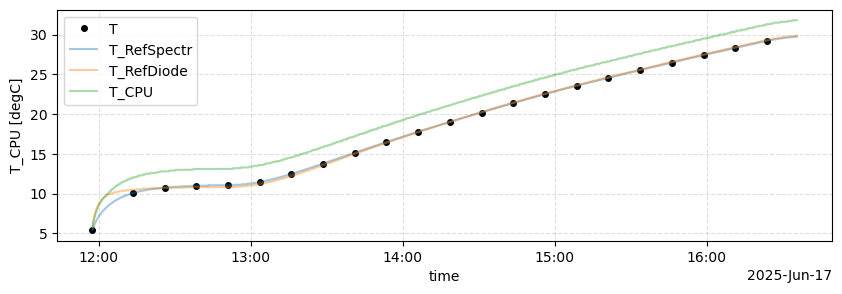

In [17]:
fig, ax = plt.subplots(1, figsize=[10,3], sharex=True)
ds['T'][::100].plot(lw=0, marker='o', ms=4, c='k', ax=ax, label='T')
ds['T_RefSpectr'].plot(alpha=0.4, label='T_RefSpectr')
ds['T_RefDiode'].plot(alpha=0.4, label='T_RefDiode')
ds['T_CPU'].plot(alpha=0.4, label='T_CPU')

ax.legend()
ax.grid(ls='--', alpha=0.4)
# ax.legend()

In [18]:
# fig, ax = plt.subplots(4,1, figsize=[10,6], sharex=True)

# ds2plot = ds.sel(time=slice(t0, t1))

# ds2plot['lampR1'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[0], label=None)
# ds2plot['lampR0'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[1])
# ds2plot['T_CPU'].plot(lw=0., marker='.', ms=1, alpha=0.5, ax=ax[2])
# ds2plot['T_RefDiode'].plot(lw=0., marker='.', ms=1, alpha=0.5, ax=ax[2])
# ds2plot['T_RefSpectr'].plot(lw=0., marker='.', ms=1, alpha=0.5, ax=ax[2])
# ds2plot['Fcount'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[3])

# ax[2].grid(ls='--', alpha=0.4)


# # ax[3].set_xlim([pd.to_datetime('2025-06-17 11:40'), pd.to_datetime('2025-06-17 12:45')])

In [19]:

ds2 = ds.sel(   time=slice('2025-06-17 13:15',   '2025-06-17 16:00' )  ) # this is to ensure that the temperature distribution is uniform

i200_255 = np.where( (ds2['wv'] >= 200) & (ds2['wv'] <= 255) )



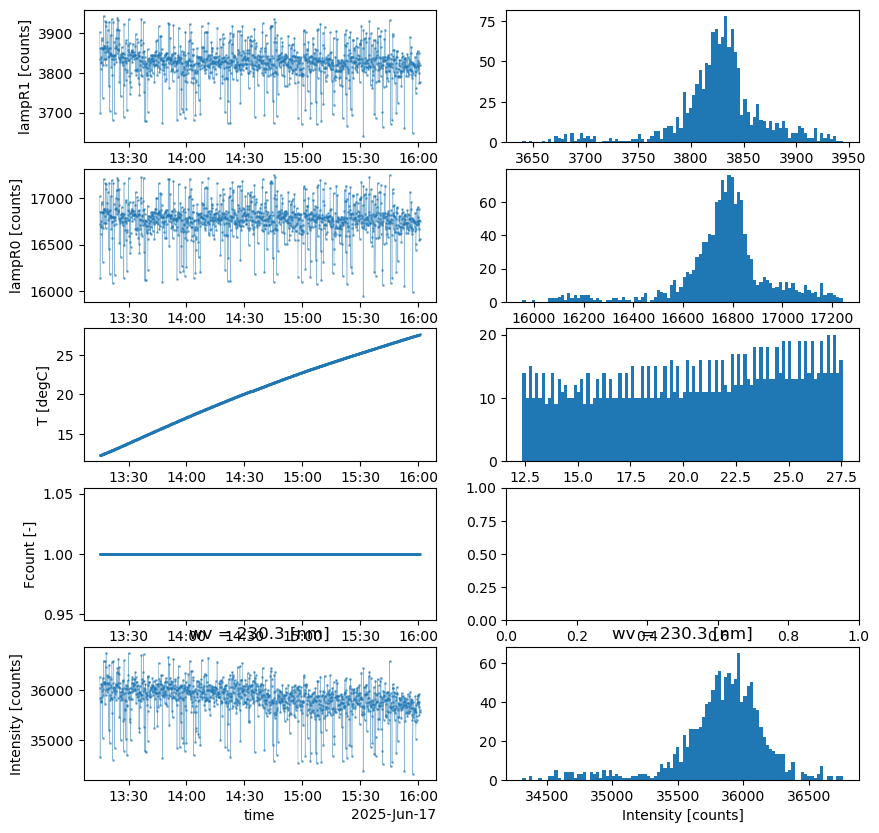

In [10]:
iwv = 50


fig, ax = plt.subplots(5,2, figsize=[10,10], sharex=False)

ds2['lampR1'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[0,0], label=None)
ax[0,0].set_xlabel('')
ds2['lampR0'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[1,0])
ax[1,0].set_xlabel('')
ds2['T'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[2,0])
ax[2,0].set_xlabel('')
ds2['Fcount'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[3,0])
ax[3,0].set_xlabel('')

ds2['Intensity'][:,iwv].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[4,0])



ds2['lampR1'].plot.hist(bins=100, ax=ax[0,1]); 
ds2['lampR0'].plot.hist(bins=100, ax=ax[1,1]);
ds2['T'].plot.hist(bins=100, ax=ax[2,1]);
ds2['Intensity'][:,iwv].plot.hist(bins=100, ax=ax[4,1]);


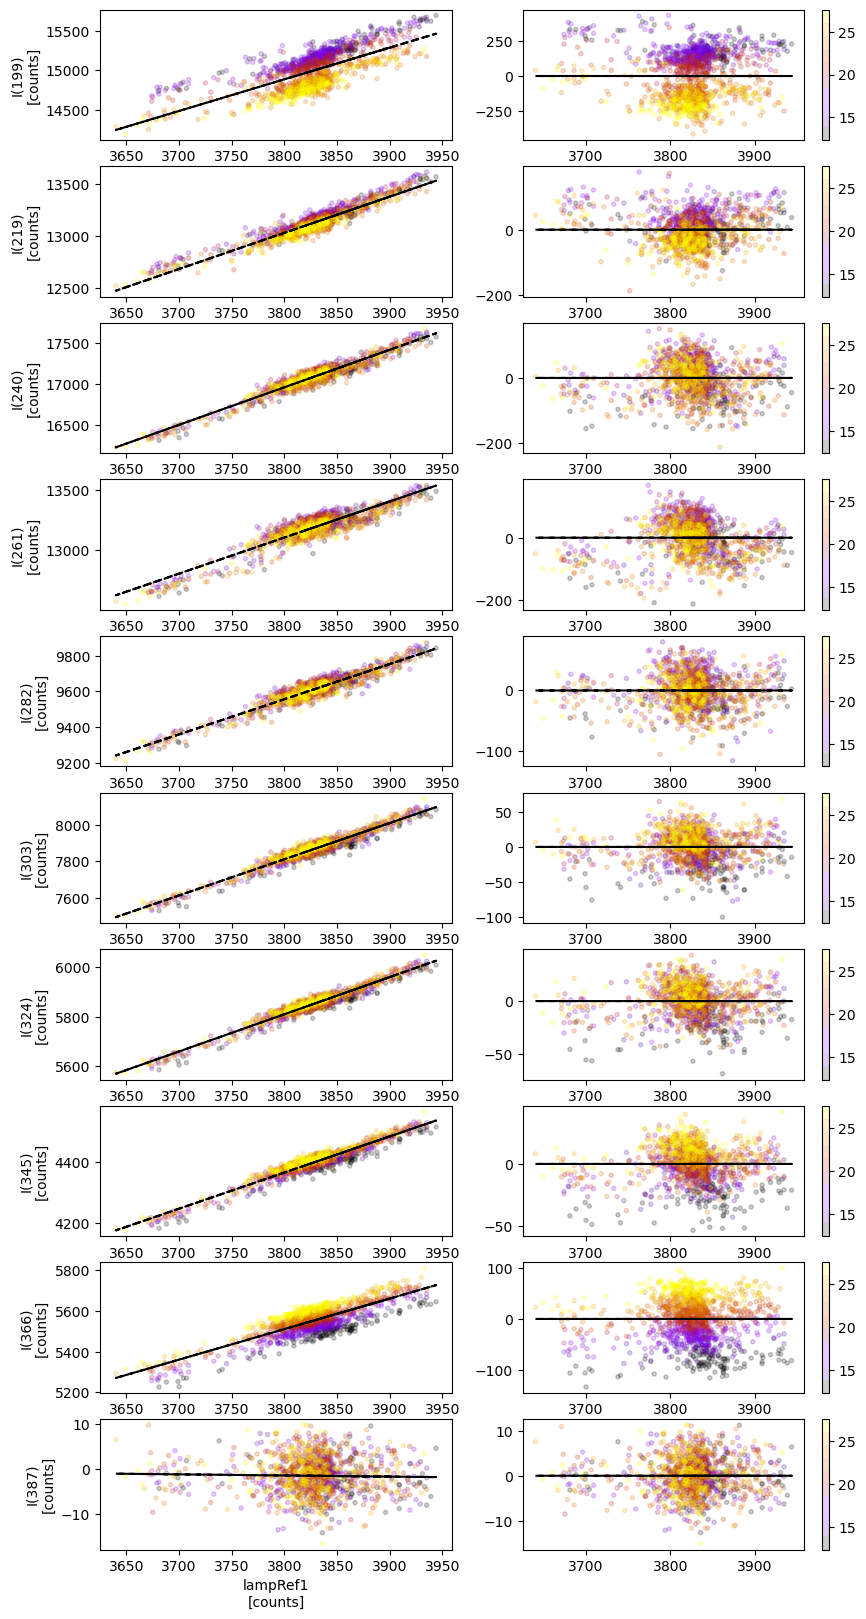

In [11]:
m = np.empty(wv.size) * np.nan
q = np.empty(wv.size) * np.nan

n_plots = 10
fig, ax = plt.subplots(n_plots, 2, figsize=[10,2*n_plots])



for ii,ip in enumerate(np.linspace(11, wv.size, n_plots).astype(int)-1):
    h = ax[ii,0].scatter(ds2['lampR1'], ds2['Intensity'][:,ip].T, c=ds2['T'], 
                         marker='.',
                         alpha=0.2, 
                         # vmin=24, vmax=25, 
                         cmap=plt.get_cmap('gnuplot', 10));
    
    ax[ii,0].set_ylabel(f'I({wv[ip]:.0f})\n[counts]')
    ax[ii,0].set_xlabel(f'lampRef1\n[counts]')

    m[ii], q[ii] = np.polyfit(ds2['lampR1'], ds2['Intensity'][:,ip], 1)
    
    pred = m[ii] * ds2['lampR1'] + q[ii]
    ax[ii,0].plot(ds2['lampR1'], pred, 'k--')
    
    h = ax[ii,1].scatter(ds2['lampR1'], ds2['Intensity'][:,ip].T - pred, c=ds2['T'],  #TrefDiode_i[iLT24], 
                         marker='.',
                         alpha=0.2, 
                         # vmin=24, vmax=25, 
                         cmap=plt.get_cmap('gnuplot', 10));
    
    ax[ii,1].plot(ds2['lampR1'], ds2['lampR1'][:]*0, 'k--')
    
    fig.colorbar(h)

### Plot T dependency

In [12]:
# select range of lampR1 to use to see T dependency
iLampRef = np.where( (ds2['lampR1'] >= 3800) &
                     (ds2['lampR1'] <= 3850)
                   )[0]



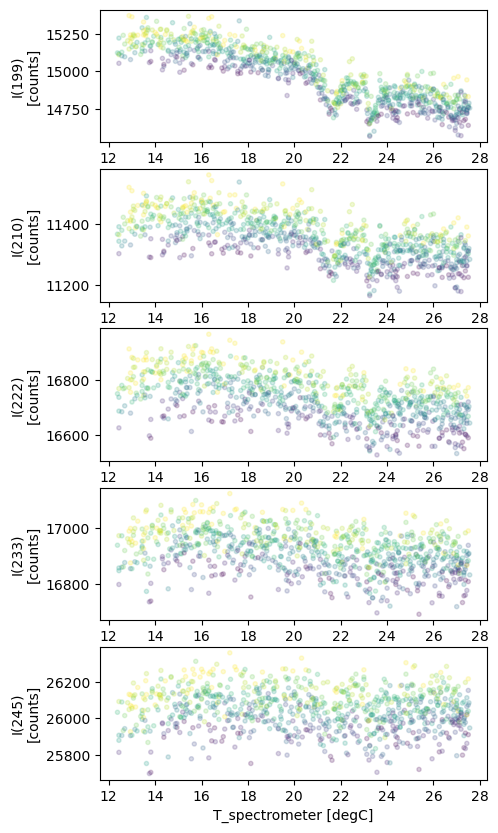

In [13]:
n_plots = 5
fig, ax = plt.subplots(n_plots, 1, figsize=[5, 2*n_plots])


for ii,ip in enumerate(np.linspace(11, wv[i200_255].size, n_plots).astype(int)-1):
    h = ax[ii].scatter(ds2['T'][iLampRef], ds2['Intensity'][iLampRef,ip].T, c=ds2['lampR1'][iLampRef], 
                         marker='.',
                         alpha=0.2, 
                         # vmin=24, vmax=25, 
                         cmap=plt.get_cmap('viridis', 10));

    # ax[ii].plot(ds2['T'][iLampRef], ds2['T'][iLampRef]*m_T[ip] + ds2['Intensity'][iLampRef[500],ip], 'k--')
    
    ax[ii].set_ylabel(f'I({wv[ip]:.0f})\n[counts]')
    ax[ii].set_xlabel(f'T_spectrometer [degC]')



In [14]:
#  fit lRef1 and T dependences
T_col = 'T'
[m_lRef_rob, m_T_rob, q_rob] = op.cmp_R_T_corr_robust(ds2, T_col, DIN)
[m_lRef1, m_T] = op.cmp_R_T_corr(ds2, T_col, DIN)


Text(0, 0.5, 'm_T')

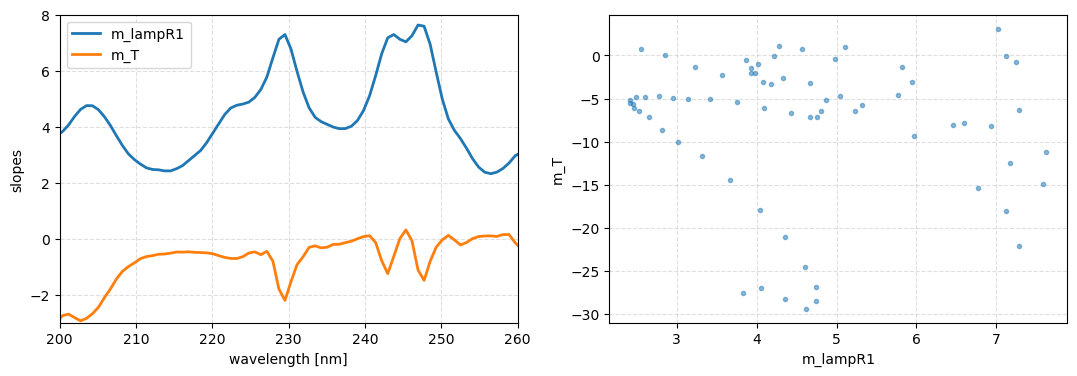

In [15]:
i200_255 = np.where( (ds2['wv'] >= 200) & (ds2['wv'] <= 255) )

fig, ax = plt.subplots(1,2, figsize=[13, 4])
# ax[0].plot(wv, m, '.-', ms=2, lw=0.5, label='m_lampR1_noT')
ax[0].plot(ds2['wv'][:], m_lRef1[:], lw=2, label='m_lampR1')
# ax[0].plot(ds2['wv'][:], m_lRef_rob[:], lw=0.5, label='m_lampR1_robust')


ax[0].plot(ds2['wv'][:], m_T[:]/10, lw=2, label='m_T')
# ax[0].plot(ds2['wv'][:], m_T_rob[:]/10, lw=0.5, label='m_T_robust')
ax[0].legend()
ax[0].grid(ls='--', alpha=0.4)
ax[0].set_xlabel('wavelength [nm]')
ax[0].set_ylabel('slopes')
ax[0].set_ylim([-3, 8])
ax[0].set_xlim([200, 260])

ax[1].plot(m_lRef1[i200_255], m_T[i200_255], '.', alpha=0.5)
ax[1].grid(ls='--', alpha=0.4)
ax[1].set_xlabel('m_lampR1')
ax[1].set_ylabel('m_T')


In [16]:
def apply_Io_corr(ds2, io, T_col, m_lRef1, m_T):
    
    Io = ds2['Intensity'][io,:]
    dR = ds2['lampR1'].values - ds2['lampR1'][io].values
    dT = ds2[T_col].values - ds2[T_col][io].values

    Io_corr  = ds2['Intensity'][io,:].values.reshape(-1,1).T +   m_lRef1 * dR.reshape(-1,1)   +   m_T * dT.reshape(-1,1)

    return Io_corr

In [22]:
io = 300

In [23]:
# apply correction

Io_R_not_corr = ds2['Intensity'][io,:].values.reshape(-1,1).T

Io_R_corr = apply_Io_corr(ds2, io, T_col, m_lRef1, m_T)
Io_R_corr_rob = apply_Io_corr(ds2, io, T_col, m_lRef_rob, m_T_rob)


T_not_corr  = ds2['Intensity'].values / Io_R_not_corr
A_not_corr  = -np.log10(np.asarray(T_not_corr))

T_corr   = ds2['Intensity'].values / Io_R_corr
A_corr = -np.log10(np.asarray(T_corr))

T_rob   = ds2['Intensity'].values / Io_R_corr_rob
A_corr_rob = -np.log10(np.asarray(T_rob))


WV  = np.ones([ds2['T'].size,1]) * wv.reshape(1,-1)

/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_76690/3771916328.py:10: RuntimeWarning: divide by zero encountered in log10
  A_not_corr  = -np.log10(np.asarray(T_not_corr))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_76690/3771916328.py:10: RuntimeWarning: invalid value encountered in log10
  A_not_corr  = -np.log10(np.asarray(T_not_corr))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_76690/3771916328.py:13: RuntimeWarning: divide by zero encountered in log10
  A_corr = -np.log10(np.asarray(T_corr))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_76690/3771916328.py:13: RuntimeWarning: invalid value encountered in log10
  A_corr = -np.log10(np.asarray(T_corr))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_76690/3771916328.py:16: RuntimeWarning: divide by zero encountered in log10
  A_corr_rob = -np.log10(np.asarray(T_rob))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_76690/3771916328.py:16: RuntimeWarning: in

Text(164.22222222222223, 0.5, 'absorbance [-]')

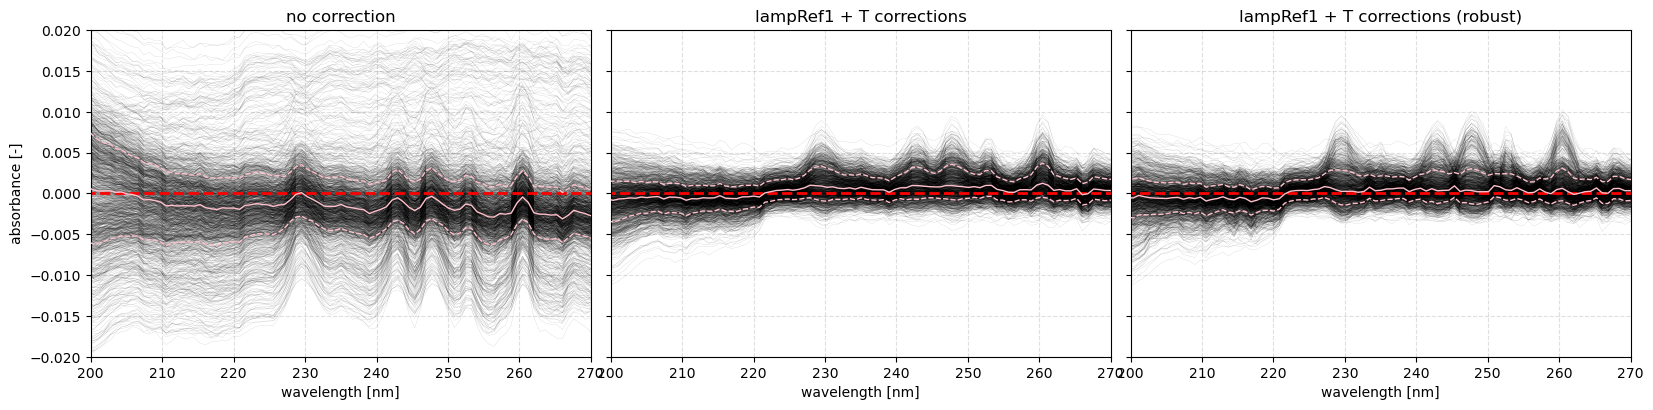

In [24]:
def make_line_collection(x, y_array, **kwargs):
    """
    Creates a LineCollection from a set of y-series sharing the same x-axis.
    x: 1D array of shape (M,)
    y_array: 2D array of shape (N, M)
    """
    # Each line segment is an array of shape (M, 2)
    segments = [np.column_stack((x, y)) for y in y_array]
    return LineCollection(segments, **kwargs)

fig, ax = plt.subplots(1, 3, figsize=[16, 4], sharex=True, sharey=True)

datasets = [
    (A_not_corr, 0),
    (A_corr, 1),
    (A_corr_rob, 2)
]

for data, i in datasets:
    # Ensure data is shaped (N, M) where M == len(wv)
    if data.shape[1] != len(wv):
        data = data.T  # transpose if needed

    lc = make_line_collection(wv, data, colors='k', linewidths=0.1, alpha=0.4)
    ax[i].add_collection(lc)
    
    ax[i].plot(wv, np.zeros_like(wv), lw=2, ls='--', c='r', alpha=1)

    median = np.nanmedian(data, axis=0)
    p16 = np.nanpercentile(data, 16, axis=0)
    p84 = np.nanpercentile(data, 84, axis=0)

    ax[i].plot(wv, median, lw=1, c='pink', zorder=60)
    ax[i].plot(wv, p84, '--', lw=1, c='pink', zorder=60)
    ax[i].plot(wv, p16, '--', lw=1, c='pink', zorder=60)

    ax[i].autoscale()  # Important when using LineCollection

    ax[i].set_xlabel('wavelength [nm]')
    ax[i].grid(ls='--', alpha=0.4)
    
plt.tight_layout()


ax[0].set_xlim([200, 270])
ax[0].set_ylim([-0.02, 0.02])
# ax[2].set_ylim([-0.025, 0.01])


ax[0].set_title('no correction')
ax[1].set_title('lampRef1 + T corrections')
ax[2].set_title('lampRef1 + T corrections (robust)')

ax[0].set_ylabel('absorbance [-]')
# ax[0].set_ylabel('absorbance [-]')

In [25]:
def cv_rob(x):
    return np.abs((np.nanpercentile(x, 84) - np.nanpercentile(x, 16)) / 2 / np.nanpercentile(x, 50))

i200_235 = np.where((ds2['wv'] >= 200) & (ds2['wv'] <= 240))[0]

A_flat = A_not_corr[:,i200_235].flatten()
innan = np.where(~np.isnan(A_flat))[0]
print(f'{np.nanmedian(A_flat[innan]):+.4f}', f'{cv_rob(A_flat[innan]):8.2f}')


# Aflat = A[:,i200_235].flatten()
# innan = np.where(~np.isnan(Aflat))[0]
# print(f'{np.nanmedian(Aflat[innan]):+.4f}', f'{cv_rob(Aflat[innan]):8.2f}')


A__flat = A_corr[:,i200_235].flatten()
innan = np.where(~np.isnan(A__flat))[0]
print(f'{np.nanmedian(A__flat[innan]):+.4f}', f'{cv_rob(A__flat[innan]):8.2f}')


A__flat_rob = A_corr_rob[:,i200_235].flatten()
innan = np.where(~np.isnan(A__flat_rob))[0]
print(f'{np.nanmedian(A__flat_rob[innan]):+.4f}', f'{cv_rob(A__flat_rob[innan]):8.2f}')

-0.0013     3.25
-0.0000   174.04
-0.0001    17.50


In [203]:
# i0 = 1
# +0.0006     7.31
# -0.0021     1.06
# -0.0022     1.06

# i0 = 500
# -0.0083     0.63
# +0.0017     1.71
# +0.0017     1.94

# i0 = 1000
# -0.0030     1.46
# -0.0004     4.89
# -0.0004     4.90

# i0 = 1300
# -0.0026     1.61
# -0.0006     2.77
# -0.0005     3.18

# To do
### - collect more data at lower T?
### - check what the other Ts were doing during during experiment ✅
### - How do we deal with the transient when the instrument switches on? (see T dependency plots when all data are included)
### - Write equations with $\epsilon_{NO3}$ and $\epsilon_{PSAL}$ corrected for ``lampRef1`` and ``T``
### - Compare slopes between different experiments (including air-only experiment)
### - Is there a dependency (in the final result) on ``io``?